In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the brute-force LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780     # fixed: not searched
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out


# Broad priors — same bounds as run_lhs_noise_sc_brute.py. xI0 (only 1.0 is
# valid for the waveform model) and Phi_theta0 are held fixed (not
# searched); sky/spin polar angles sampled uniform in cosine.
LOGM1_LIM = [5.6,  6.4]
LOGM2_LIM = [1.7,  2.3]
A_LIM     = [0.3,  0.999]
P0_LIM    = [13.5,  16.5]
E0_LIM    = [0.6,  0.9]
DIST_LIM  = [3,  5]
COSQS_LIM = [-1.0, 1.0]
PHIS_LIM  = [0.0,  2 * np.pi]
COSQK_LIM = [-1.0, 1.0]
PHIK_LIM  = [0.0,  2 * np.pi]
PHIPHI0_LIM = [0.0, 2 * np.pi]
PHIR0_LIM   = [0.0, 2 * np.pi]


def prior_transform(u):
    t = np.zeros_like(u)
    t[:, 0]  = (LOGM1_LIM[1] - LOGM1_LIM[0]) * u[:, 0] + LOGM1_LIM[0]
    t[:, 1]  = (LOGM2_LIM[1] - LOGM2_LIM[0]) * u[:, 1] + LOGM2_LIM[0]
    t[:, 2]  = (A_LIM[1] - A_LIM[0]) * u[:, 2] + A_LIM[0]
    t[:, 3]  = (P0_LIM[1] - P0_LIM[0]) * u[:, 3] + P0_LIM[0]
    t[:, 4]  = (E0_LIM[1] - E0_LIM[0]) * u[:, 4] + E0_LIM[0]
    t[:, 5]  = (DIST_LIM[1] - DIST_LIM[0]) * u[:, 5] + DIST_LIM[0]
    t[:, 6]  = (COSQS_LIM[1] - COSQS_LIM[0]) * u[:, 6] + COSQS_LIM[0]
    t[:, 7]  = (PHIS_LIM[1] - PHIS_LIM[0]) * u[:, 7] + PHIS_LIM[0]
    t[:, 8]  = (COSQK_LIM[1] - COSQK_LIM[0]) * u[:, 8] + COSQK_LIM[0]
    t[:, 9]  = (PHIK_LIM[1] - PHIK_LIM[0]) * u[:, 9] + PHIK_LIM[0]
    t[:, 10] = (PHIPHI0_LIM[1] - PHIPHI0_LIM[0]) * u[:, 10] + PHIPHI0_LIM[0]
    t[:, 11] = (PHIR0_LIM[1] - PHIR0_LIM[0]) * u[:, 11] + PHIR0_LIM[0]
    return t


def inverse_prior_transform(params):
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0]  = (params[:, 0] - LOGM1_LIM[0]) / (LOGM1_LIM[1] - LOGM1_LIM[0])
    u[:, 1]  = (params[:, 1] - LOGM2_LIM[0]) / (LOGM2_LIM[1] - LOGM2_LIM[0])
    u[:, 2]  = (params[:, 2] - A_LIM[0]) / (A_LIM[1] - A_LIM[0])
    u[:, 3]  = (params[:, 3] - P0_LIM[0]) / (P0_LIM[1] - P0_LIM[0])
    u[:, 4]  = (params[:, 4] - E0_LIM[0]) / (E0_LIM[1] - E0_LIM[0])
    u[:, 5]  = (params[:, 5] - DIST_LIM[0]) / (DIST_LIM[1] - DIST_LIM[0])
    u[:, 6]  = (params[:, 6] - COSQS_LIM[0]) / (COSQS_LIM[1] - COSQS_LIM[0])
    u[:, 7]  = (params[:, 7] - PHIS_LIM[0]) / (PHIS_LIM[1] - PHIS_LIM[0])
    u[:, 8]  = (params[:, 8] - COSQK_LIM[0]) / (COSQK_LIM[1] - COSQK_LIM[0])
    u[:, 9]  = (params[:, 9] - PHIK_LIM[0]) / (PHIK_LIM[1] - PHIK_LIM[0])
    u[:, 10] = (params[:, 10] - PHIPHI0_LIM[0]) / (PHIPHI0_LIM[1] - PHIPHI0_LIM[0])
    u[:, 11] = (params[:, 11] - PHIR0_LIM[0]) / (PHIR0_LIM[1] - PHIR0_LIM[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_merge_brute_smol'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
sampler.config

SamplerConfig(seed=6342, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [5]:
sampler.now_covariances

[array([[ 1.45551163e-04,  3.88667655e-05,  4.61994907e-04,
         -7.14840509e-04, -4.74738455e-05,  2.54531172e-03,
          8.59486858e-05,  1.11894340e-04,  3.39863499e-05,
         -7.64240680e-05, -4.56601007e-04,  5.22877368e-04],
        [ 3.88667655e-05,  1.44647481e-05,  1.23143541e-04,
         -1.88834477e-04, -1.43898110e-05,  4.84085940e-04,
          2.59396856e-05,  3.81064390e-05,  3.87393102e-06,
         -1.97346453e-05, -1.41210447e-04,  1.57900949e-04],
        [ 4.61994907e-04,  1.23143541e-04,  1.48961672e-03,
         -2.30303477e-03, -1.51342319e-04,  8.15179075e-03,
          2.84626164e-04,  3.43319731e-04,  1.53464782e-04,
         -2.48412550e-04, -1.51533169e-03,  1.68389987e-03],
        [-7.14840509e-04, -1.88834477e-04, -2.30303477e-03,
          3.57061103e-03,  2.33692829e-04, -1.28725268e-02,
         -4.25971787e-04, -5.61528710e-04, -1.75128988e-04,
          3.33079195e-04,  2.27157362e-03, -2.58431611e-03],
        [-4.74738455e-05, -1.4389811

In [6]:
len(sampler.now_covariances)

4

In [7]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82783552,  1.99310637,  0.50130309, 15.70697013,  0.74418544,
         3.97688723,  0.79852328,  3.74416169,  0.22894789,  4.09004734,
         2.34095757,  3.62570792]])

In [8]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.8178984 ,  1.993107  ,  0.47189751, 15.89614812,  0.74494217,
         4.81729945, -0.59109669,  0.53324016,  0.93426046,  3.44517003,
         2.01050767,  4.22187022]])

In [9]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[ 5.83252897e+00,  1.99410778e+00,  5.16310256e-01,
         1.56091753e+01,  7.43750289e-01,  4.24248445e+00,
        -5.46445493e-01,  6.07561342e+00,  3.64901590e-01,
         3.33979382e+00,  3.33946527e+00,  9.36427645e-03]])

In [10]:
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4

array([[ 6.03578833,  2.13392681,  0.54234795, 16.88241231,  0.77378014,
         4.54870516,  0.25980074, -0.86724655, -0.46278466,  2.92811009,
         1.77055578,  3.28150531]])

In [11]:
log_density(maxld_pt1), log_density(maxld_pt2), log_density(maxld_pt3), log_density(maxld_pt4)

(array([95.27954175]),
 array([53.66248492]),
 array([67.25386014]),
 array([15.49987328]))

In [12]:
log_density([param_true])

array([100.65186542])

In [13]:
param_ranges = [(LOGM1_LIM[0], LOGM1_LIM[1]),
                (LOGM2_LIM[0], LOGM2_LIM[1]),
                (A_LIM[0], A_LIM[1]),
                (P0_LIM[0], P0_LIM[1]),
                (E0_LIM[0], E0_LIM[1]),
                (DIST_LIM[0], DIST_LIM[1]),
                (COSQS_LIM[0], COSQS_LIM[1]),
                (PHIS_LIM[0], PHIS_LIM[1]),
                (COSQK_LIM[0], COSQK_LIM[1]),
                (PHIK_LIM[0], PHIK_LIM[1]),
                (PHIPHI0_LIM[0], PHIPHI0_LIM[1]),
                (PHIR0_LIM[0], PHIR0_LIM[1])]

In [14]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 4.755,
 0.8306067129371271,
 3.5808,
 0.38950706335529234,
 3.8495,
 3.194,
 0.6038]

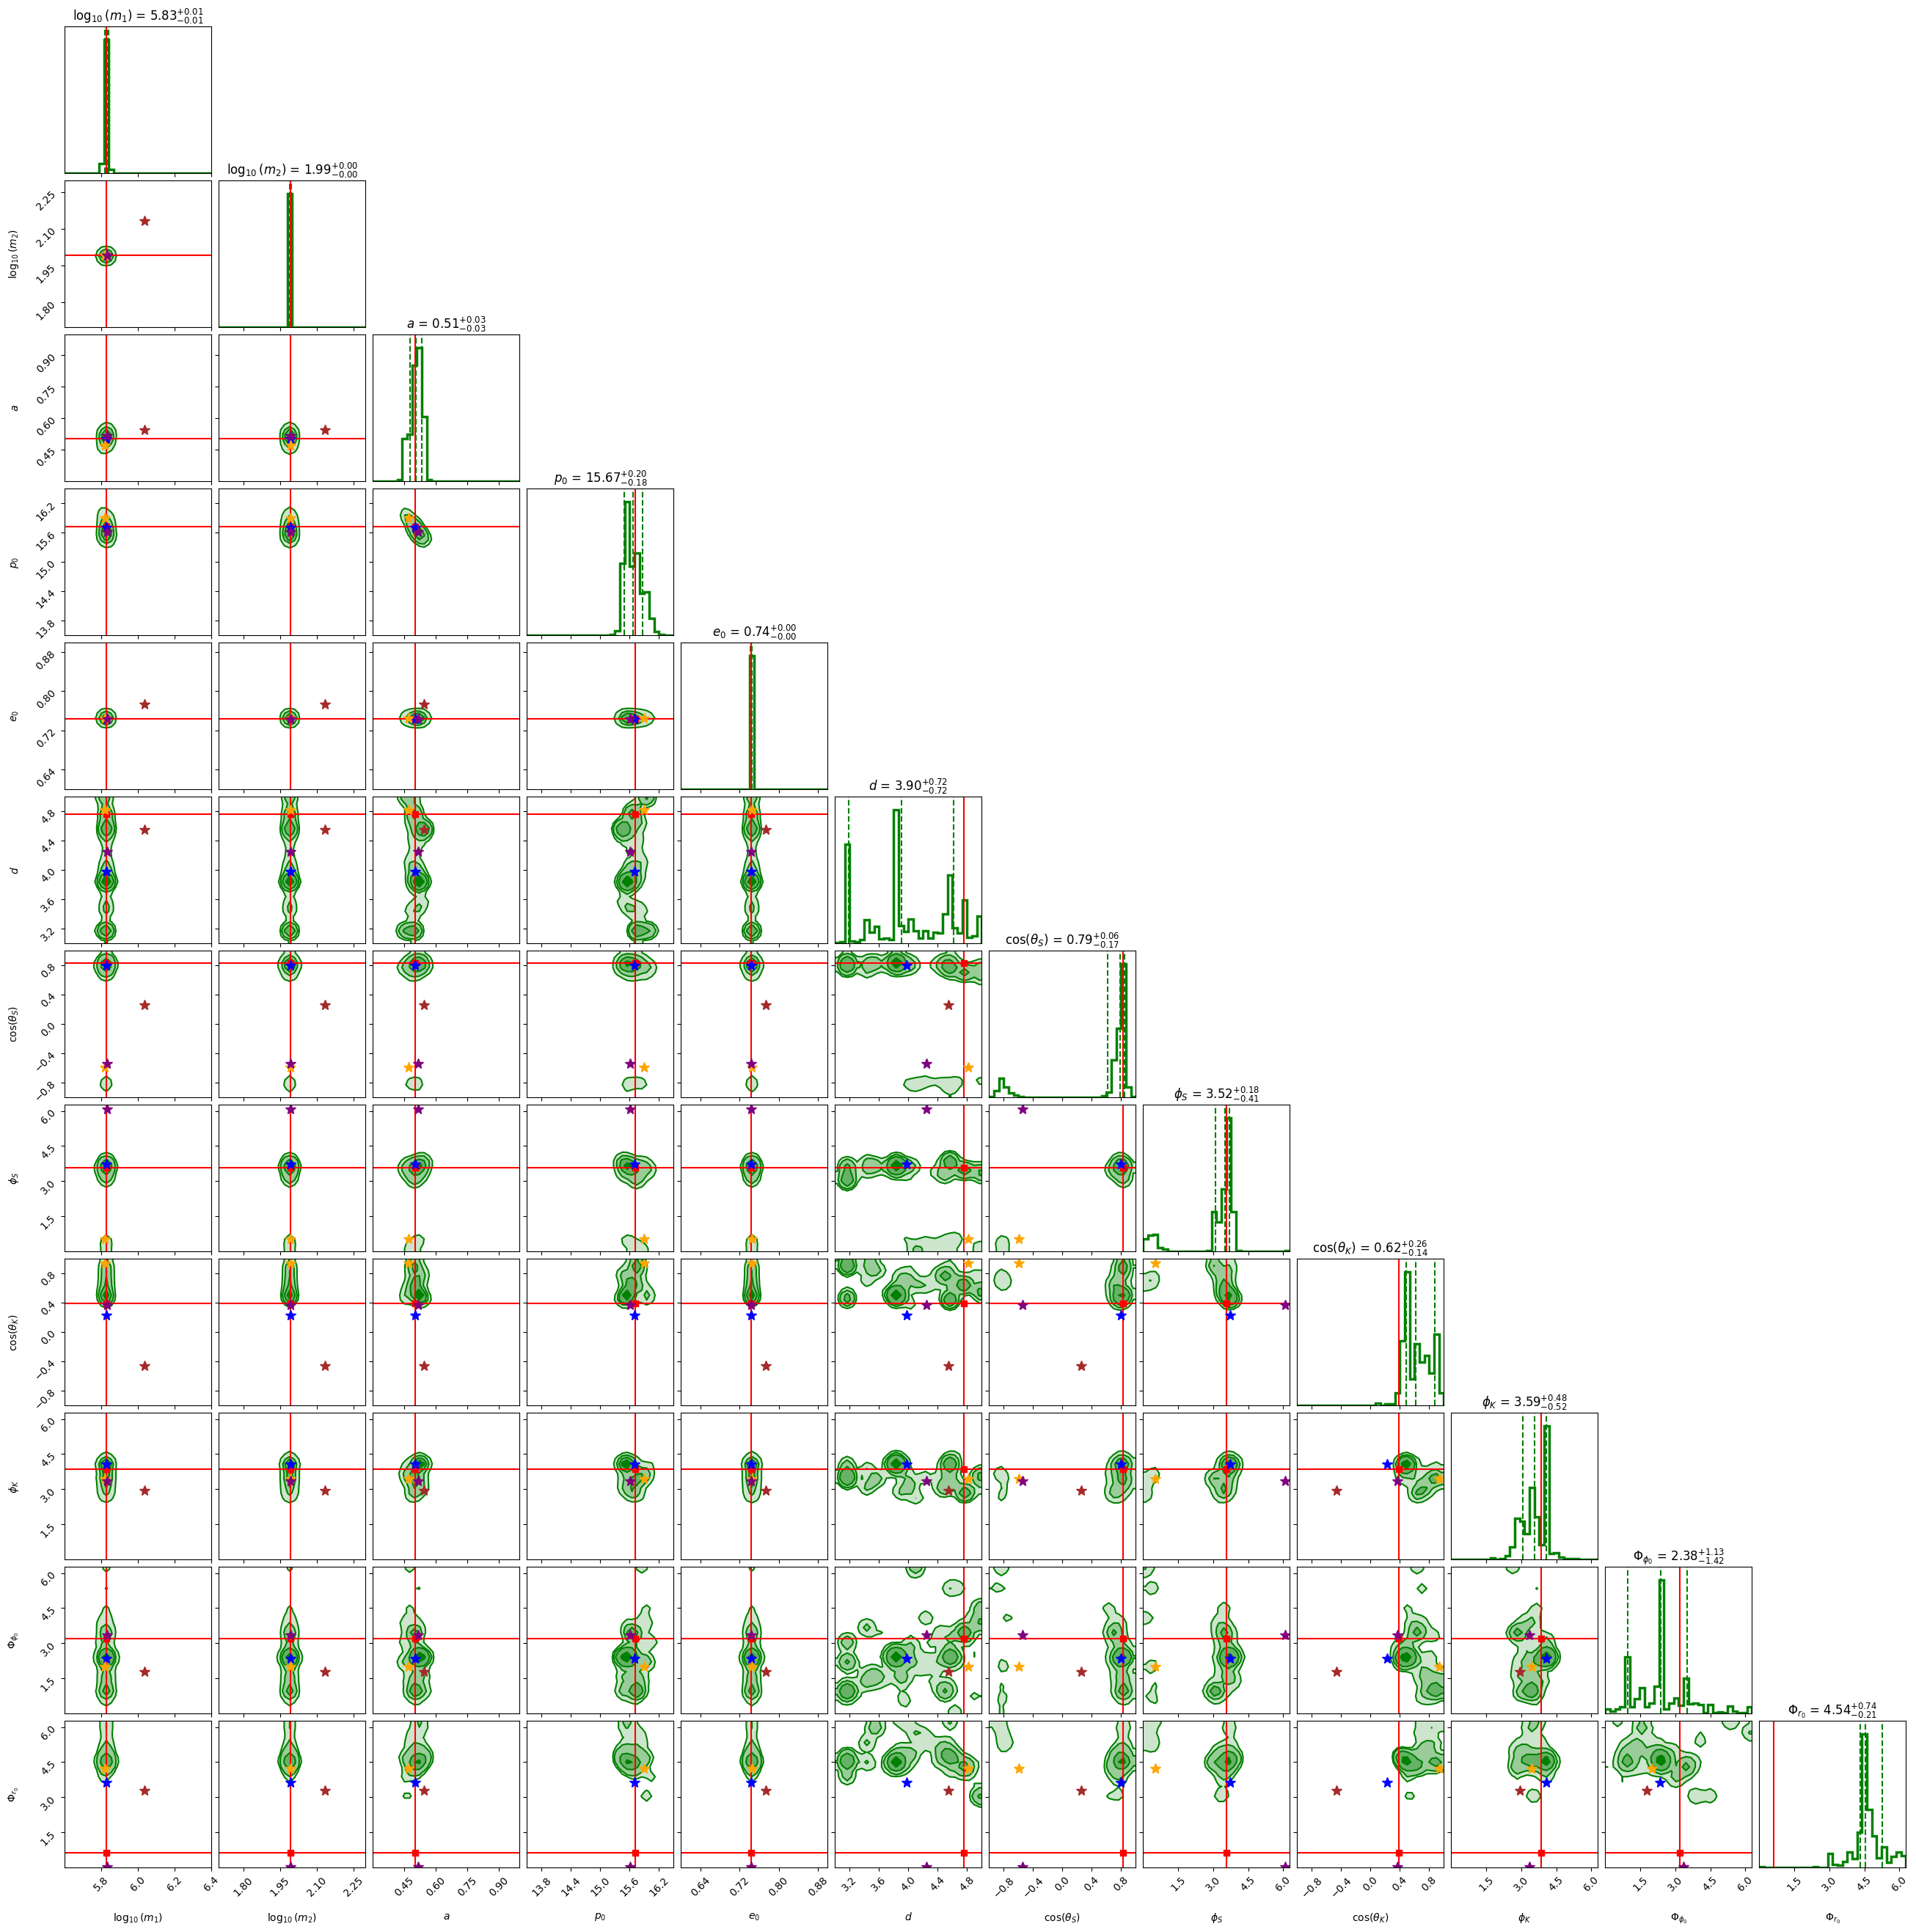

In [15]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos(\theta_S)$', r'$\phi_S$', r'$\cos(\theta_K)$', r'$\phi_K$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)


corner.overplot_points(fig, maxld_pt2.reshape(1, -1),
                       color='orange', marker='*', ms=10,
                       reverse=False)   

corner.overplot_points(fig, maxld_pt3.reshape(1, -1),
                       color='purple', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
                       color='brown', marker='*', ms=10,
                       reverse=False)

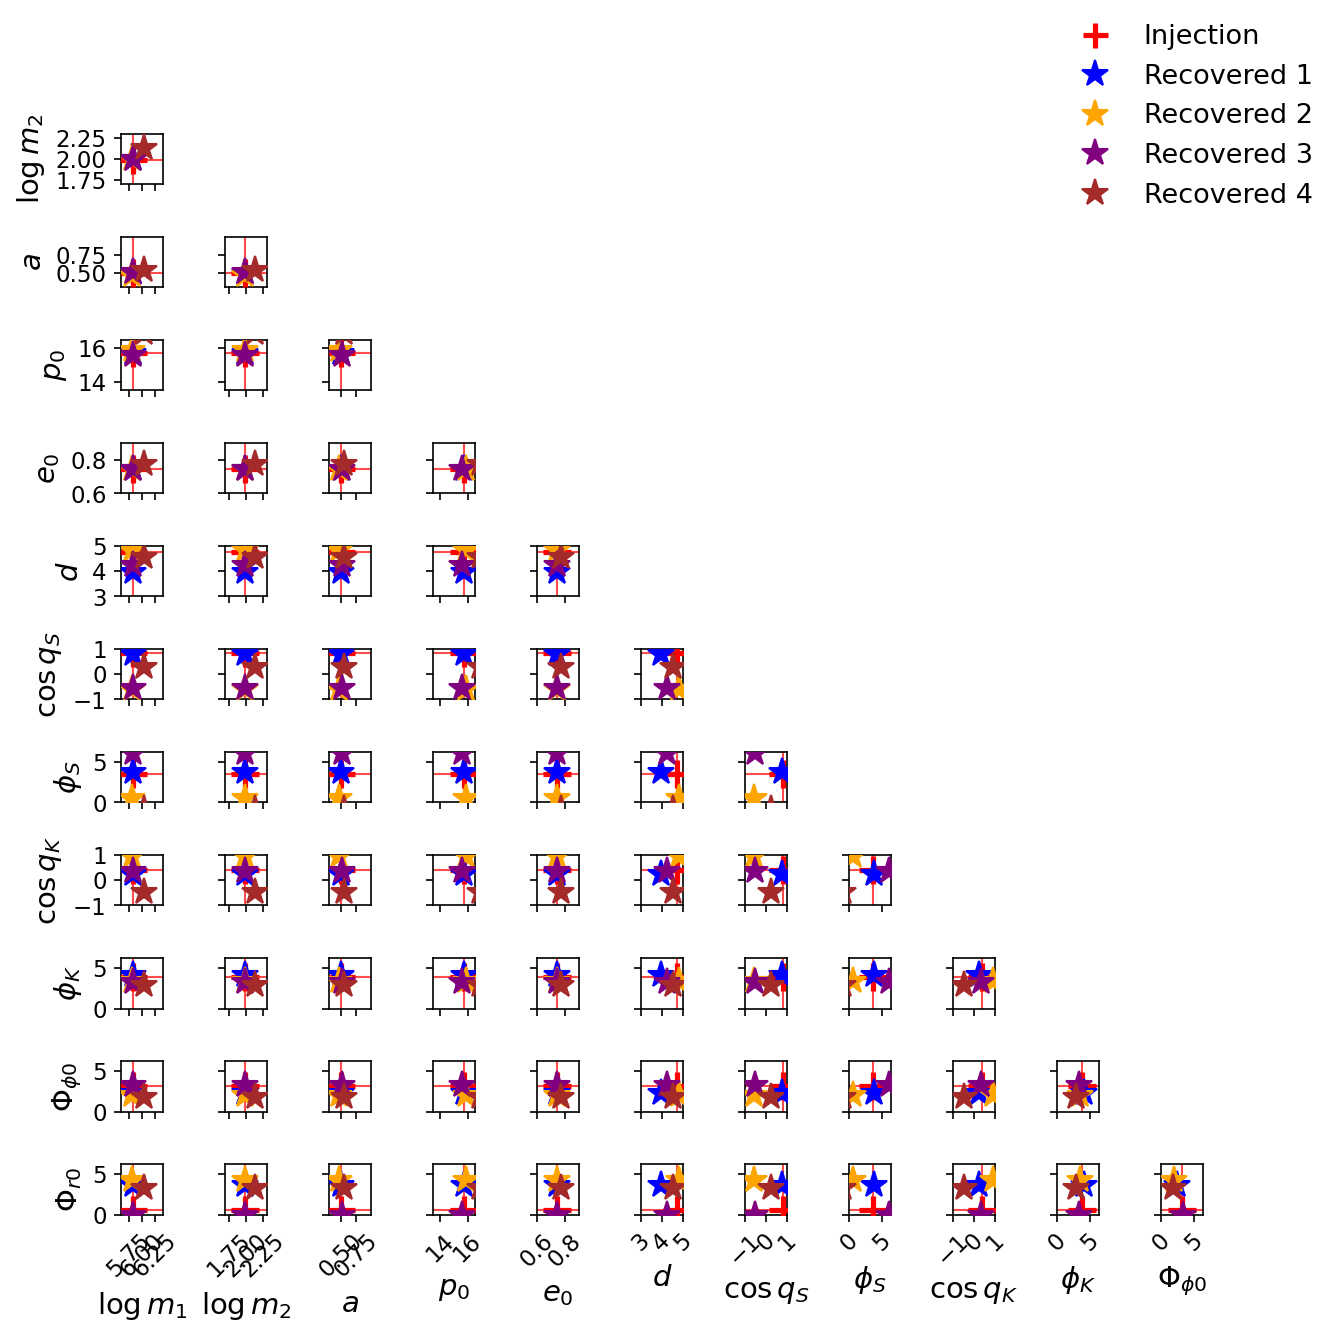

In [29]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos q_S$', r'$\phi_S$', r'$\cos q_K$', r'$\phi_K$', r'$\Phi_{\phi0}$', r'$\Phi_{r0}$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='purple',
                ms=13, zorder=4)
        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='brown',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,        label='Recovered 2'),
    Line2D([0], [0], color='purple', marker='*', ls='', ms=13,        label='Recovered 3'),
    Line2D([0], [0], color='brown', marker='*', ls='', ms=13,          label='Recovered 4')
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [17]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82783552,  1.99310637,  0.50130309, 15.70697013,  0.74418544,
         3.97688723,  0.79852328,  3.74416169,  0.22894789,  4.09004734,
         2.34095757,  3.62570792]])

In [18]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [19]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [20]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


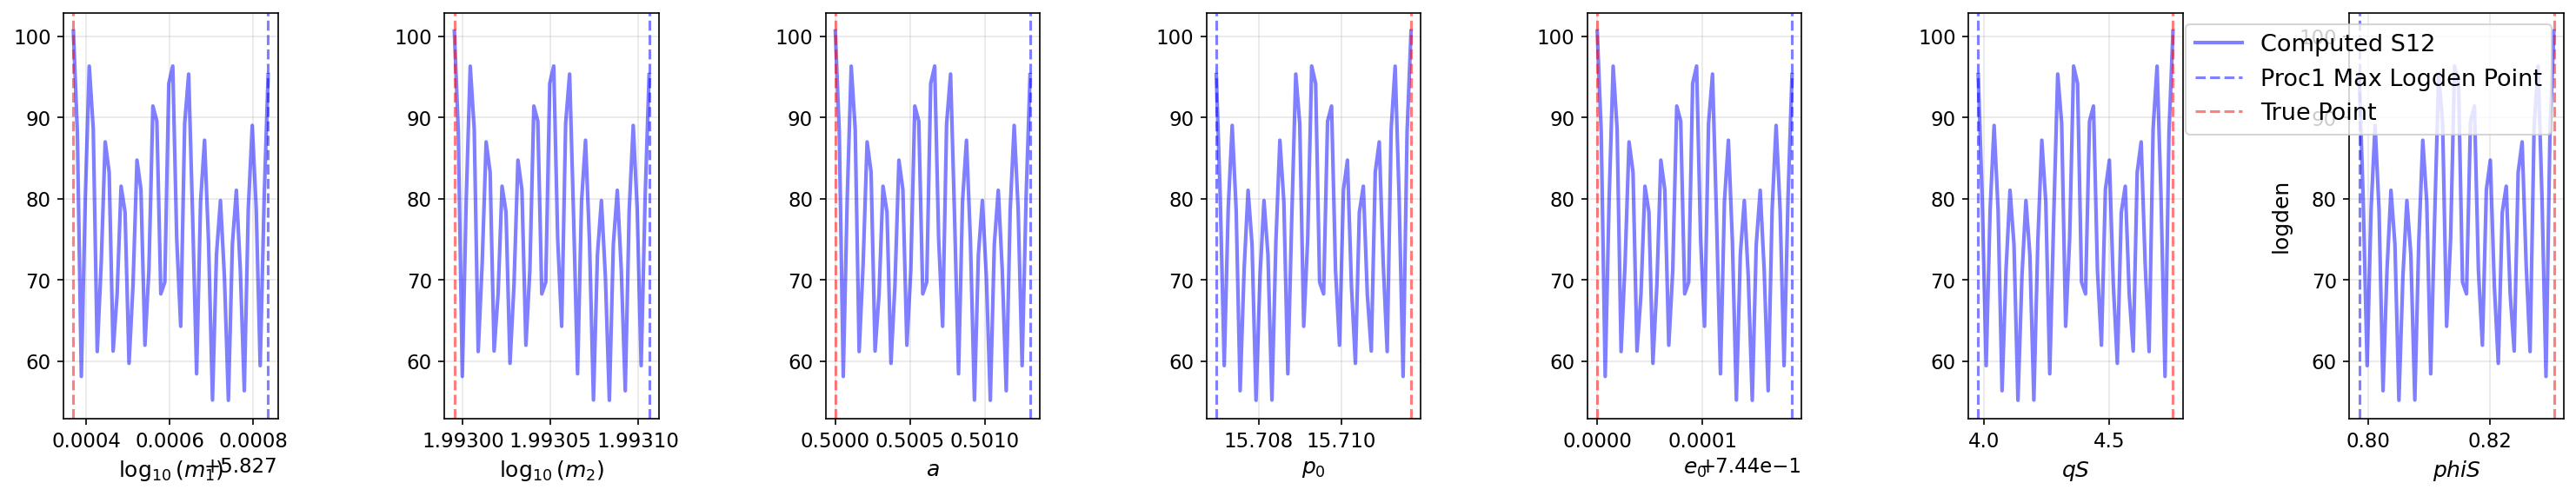

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:
def log_density_safe(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            cos_qS_i = np.clip(cos_qS_i, -1.0, 1.0)
            cos_qK_i = np.clip(cos_qK_i, -1.0, 1.0)
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out

In [23]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [24]:
i = 0  # logm1

n_dims = len(direction)
t_lo_candidates = []
t_hi_candidates = []
for d in range(n_dims):
    if direction[d] == 0:
        continue
    lo, hi = prior_lo[d], prior_hi[d]
    t_a = (lo - start[d]) / direction[d]
    t_b = (hi - start[d]) / direction[d]
    t_lo_candidates.append(min(t_a, t_b))
    t_hi_candidates.append(max(t_a, t_b))

t_lo_logm1 = max(t_lo_candidates)
t_hi_logm1 = min(t_hi_candidates)

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

# keep only inserted points that fall inside the now-tighter valid range
t_values_logm1 = np.sort(np.concatenate([
    t_values_logm1,
    [t for t in (t_true, t_secondary) if t_lo_logm1 <= t <= t_hi_logm1]
]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]

In [25]:
logden_tm = log_density_safe(line_points_logm1.T)


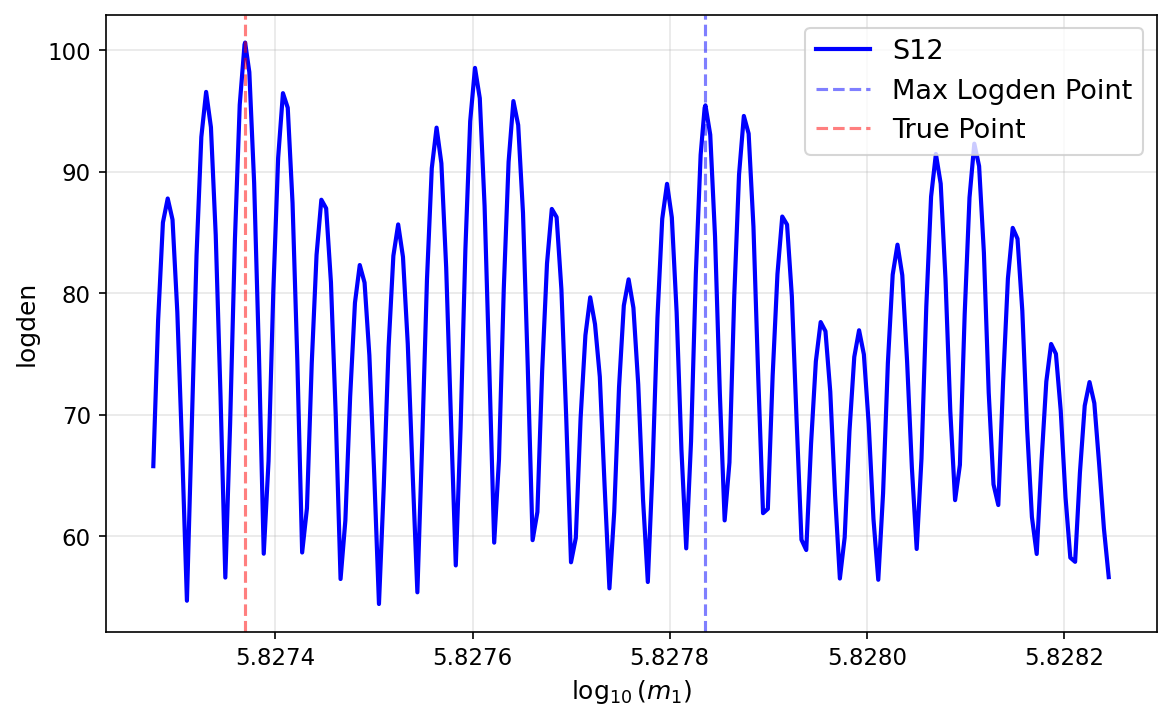

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [30]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'd', 'cos_qS', 'phiS', 'cos_qK', 'phiK', 'Phi_phi0', 'Phi_r0']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=5.82784  sigma=0.00930  true offset = -0.05 sigma
logm2   : mu=1.99311  sigma=0.00196  true offset = -0.06 sigma
a       : mu=0.50130  sigma=0.02630  true offset = -0.05 sigma
p0      : mu=15.70697  sigma=0.17585  true offset = +0.03 sigma
e0      : mu=0.74419  sigma=0.00117  true offset = -0.16 sigma
d       : mu=3.97689  sigma=0.56517  true offset = +1.38 sigma
cos_qS  : mu=0.79852  sigma=0.56120  true offset = +0.06 sigma
phiS    : mu=3.74416  sigma=1.12128  true offset = -0.15 sigma
cos_qK  : mu=0.22895  sigma=0.16753  true offset = +0.96 sigma
phiK    : mu=4.09005  sigma=0.52312  true offset = -0.46 sigma
Phi_phi0: mu=2.34096  sigma=1.17725  true offset = +0.72 sigma
Phi_r0  : mu=3.62571  sigma=0.64854  true offset = -4.66 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 4.66


In [41]:
# Prior bounds)
p1_lo = np.array([5.6, 1.7, 0.3, 13.5, 0.6])
p1_hi = np.array([6.4, 2.3, 0.99, 16.5, 0.9])

# N_SIGMA needed to cover the true point (from previous cell), rounded up
N_SIGMA = 1
print(f'N_SIGMA = {N_SIGMA:.0f}')

mu_center7 = mu_center[:5]
sigma_diag7 = sigma_diag[:5]

ellipse_lo = np.clip(mu_center7 - N_SIGMA * sigma_diag7, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center7 + N_SIGMA * sigma_diag7, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

# vol_frac = np.prod(box_width / full_width)
# print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 1
logm1   : [5.81854, 5.83713]  width=0.01859  (2.32% of full prior width)
logm2   : [1.99115, 1.99507]  width=0.00392  (0.65% of full prior width)
a       : [0.47501, 0.52760]  width=0.05259  (7.62% of full prior width)
p0      : [15.53112, 15.88282]  width=0.35169  (11.72% of full prior width)
e0      : [0.74301, 0.74536]  width=0.00235  (0.78% of full prior width)
